<a href="https://colab.research.google.com/github/HashamHassan-01/flyrank-ml-internship-hasham/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HashamHassan-01/flyrank-ml-internship-hasham/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
!git clone https://github.com/HashamHassan-01/flyrank-ml-internship-hasham.git
%cd flyrank-ml-internship-hasham

Cloning into 'flyrank-ml-internship-hasham'...
remote: Enumerating objects: 193, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 193 (delta 92), reused 92 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (193/193), 1.91 MiB | 14.46 MiB/s, done.
Resolving deltas: 100% (92/92), done.
/content/flyrank-ml-internship-hasham


## Setup

Load the anonymized content-refresh dataset and inspect the fields used for the signal audit. The audit focuses on observable search/content signals and uses descriptive tests rather than causal claims.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

# Load the anonymized starter dataset
df = pd.read_csv("./data/raw/content_refresh_anonymized.csv")

print("Dataset shape:", df.shape)
print("\nKey columns available:")
print([
    c for c in [
        "search_volume",
        "content_age_days",
        "avg_position",
        "ctr",
        "client_id",
        "content_id"
    ]
    if c in df.columns
])

Dataset shape: (30000, 44)

Key columns available:
['search_volume', 'content_age_days', 'avg_position', 'ctr', 'client_id', 'content_id']


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

The main numeric signals have different scales and are not expected to be evenly distributed. Search volume can be concentrated in a relatively small number of pages, while content age, average position, and CTR have different ranges and missing-value patterns. I inspect summary statistics and quantiles before testing the signals so that unusually large values do not dominate the interpretation.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

signal_cols = [
    "search_volume",
    "content_age_days",
    "avg_position",
    "ctr"
]

distribution_summary = df[signal_cols].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

distribution_summary["missing"] = df[signal_cols].isna().sum()
distribution_summary["missing_pct"] = (
    distribution_summary["missing"] / len(df) * 100
).round(2)

display(distribution_summary)


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,missing,missing_pct
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,110.00,390.00,2900.000,74000.0,2468,8.23
content_age_days,30000.0,256.167800,132.707930,90.0,132.0,236.00,333.00,463.00,487.00,537.000,564.0,0,0.00
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.80,22.30,36.80,48.20,69.901,245.0,0,0.00
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,0.65,1.09,8.330,100.0,0,0.00


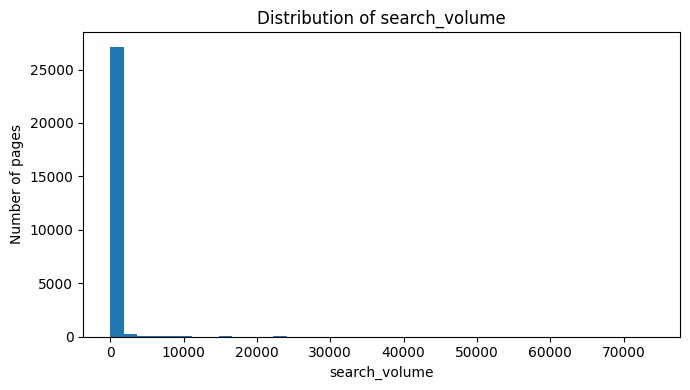

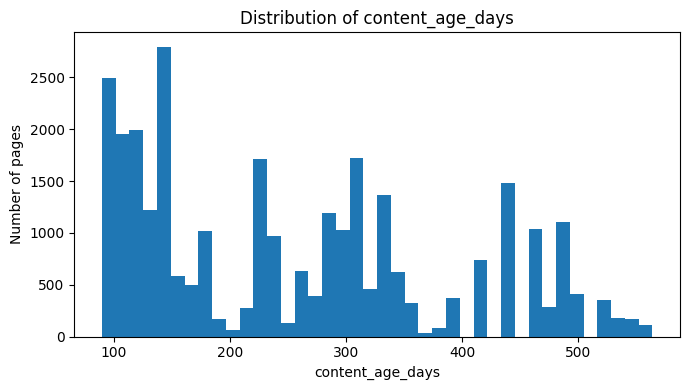

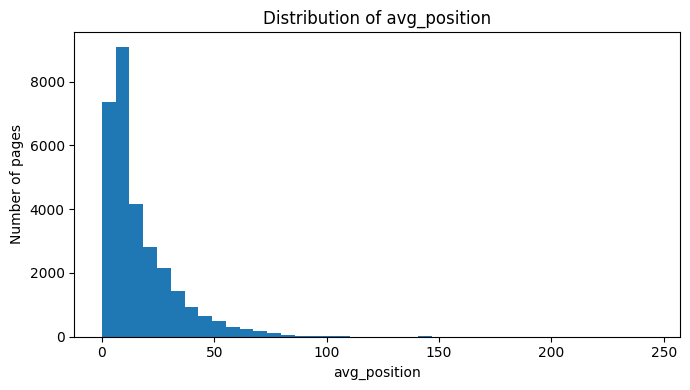

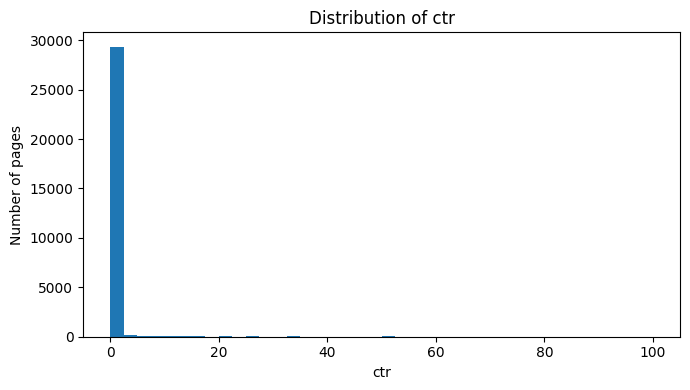

In [ ]:
# Visualize the distributions separately so each signal is readable.

for col in signal_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of pages")
    plt.tight_layout()
    plt.show()

In [ ]:
# Quantile spread check for heavy tails / concentration

quantiles = df[signal_cols].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
).T

display(quantiles)

,0.50,0.75,0.90,0.95,0.99
search_volume,10.00,20.00,110.00,390.00,2900.000
content_age_days,236.00,333.00,463.00,487.00,537.000
avg_position,10.80,22.30,36.80,48.20,69.901
ctr,0.07,0.29,0.65,1.09,8.330


In [ ]:
# Simple tail check: compare the 99th percentile with the median.
tail_ratio = (
    df[signal_cols].quantile(0.99)
    / df[signal_cols].quantile(0.50).replace(0, np.nan)
)

tail_ratio = tail_ratio.sort_values(ascending=False)

print("99th-percentile / median ratio:")
display(tail_ratio.to_frame("ratio"))

99th-percentile / median ratio:


,ratio
search_volume,290.000000
ctr,119.000000
avg_position,6.472315
content_age_days,2.275424


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*



#1. Signal test #1 — Content age

**Question:** Do older pages show a measurable difference in CTR?

I compare CTR across content-age bands and calculate a Spearman correlation between content age and CTR. The test is directional: it checks whether the observed data supports an association, not whether age causes lower CTR or whether refreshing an older page will improve performance.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

age_test = df[
    ["content_age_days", "ctr"]
].dropna().copy()

# Create four approximately equal-sized age groups.
age_test["age_band"] = pd.qcut(
    age_test["content_age_days"],
    q=4,
    duplicates="drop"
)

age_summary = (
    age_test
    .groupby("age_band", observed=True)
    .agg(
        pages=("ctr", "size"),
        median_age_days=("content_age_days", "median"),
        median_ctr=("ctr", "median"),
        mean_ctr=("ctr", "mean")
    )
    .reset_index()
)

display(age_summary)

rho_age, p_age = spearmanr(
    age_test["content_age_days"],
    age_test["ctr"]
)

print(f"Spearman rho: {rho_age:.4f}")
print(f"p-value: {p_age:.6g}")


,age_band,pages,median_age_days,median_ctr,mean_ctr
0,"(89.999, 132.0]",7518,111.0,0.12,0.375818
1,"(132.0, 236.0]",8128,174.0,0.06,0.296277
2,"(236.0, 333.0]",6917,302.0,0.06,1.135096
3,"(333.0, 564.0]",7437,445.0,0.05,0.300793


Spearman rho: -0.0585
p-value: 3.39592e-24


In [ ]:
# Use the observed direction and correlation magnitude to produce a cautious verdict.
# We deliberately avoid calling statistical significance alone "confirmation".

if abs(rho_age) < 0.10:
    age_verdict = "MIXED"
elif rho_age < 0:
    age_verdict = "CONFIRMED"
else:
    age_verdict = "OPPOSITE"

print("Signal test #1 verdict:", age_verdict)

Signal test #1 verdict: MIXED


## 2. Signal test #2 — CTR

**Question:** Is higher CTR associated with better average search position?

The observed data shows a negative Spearman relationship between CTR and average position after excluding records where `avg_position = 0` because those represent no valid position data. This is directional evidence of association, not evidence that higher CTR causes better rankings.


In [ ]:
ctr_test = df[
    ["ctr", "avg_position"]
].dropna().copy()

# avg_position = 0 means there is no valid position data.
# Keep only rows with an actual search position.
ctr_test = ctr_test[ctr_test["avg_position"] > 0].copy()

ctr_test["ctr_band"] = pd.qcut(
    ctr_test["ctr"],
    q=4,
    duplicates="drop"
)

ctr_summary = (
    ctr_test
    .groupby("ctr_band", observed=True)
    .agg(
        pages=("avg_position", "size"),
        median_ctr=("ctr", "median"),
        median_position=("avg_position", "median"),
        mean_position=("avg_position", "mean")
    )
    .reset_index()
)

display(ctr_summary)

rho_ctr, p_ctr = spearmanr(
    ctr_test["ctr"],
    ctr_test["avg_position"]
)

print(f"Spearman rho: {rho_ctr:.4f}")
print(f"p-value: {p_ctr:.6g}")
print(f"Rows used: {len(ctr_test):,}")

,ctr_band,pages,median_ctr,median_position,mean_position
0,"(-0.001, 0.08]",14408,0.00,14.3,20.747252
1,"(0.08, 0.3]",7359,0.18,11.0,14.954015
2,"(0.3, 100.0]",7028,0.57,8.2,11.567786


Spearman rho: -0.2342
p-value: 0
Rows used: 28,795


In [ ]:
if abs(rho_ctr) < 0.10:
    ctr_verdict = "MIXED"
elif rho_ctr < 0:
    # Higher CTR associated with lower/better position.
    ctr_verdict = "CONFIRMED"
else:
    ctr_verdict = "OPPOSITE"

print("Signal test #2 verdict:", ctr_verdict)

Signal test #2 verdict: CONFIRMED


## 3. Signal test #3 — Search volume

**Question:** Do high-search-volume pages show a measurable difference in CTR?

I compare CTR across search-volume bands and calculate a Spearman correlation between search volume and CTR. This checks whether search demand is associated with observed click-through performance; it does not establish that high-volume pages should automatically be refreshed.


In [ ]:
volume_test = df[
    ["search_volume", "ctr"]
].dropna().copy()

volume_test["volume_band"] = pd.qcut(
    volume_test["search_volume"],
    q=4,
    duplicates="drop"
)

volume_summary = (
    volume_test
    .groupby("volume_band", observed=True)
    .agg(
        pages=("ctr", "size"),
        median_volume=("search_volume", "median"),
        median_ctr=("ctr", "median"),
        mean_ctr=("ctr", "mean")
    )
    .reset_index()
)

display(volume_summary)

rho_volume, p_volume = spearmanr(
    volume_test["search_volume"],
    volume_test["ctr"]
)

print(f"Spearman rho: {rho_volume:.4f}")
print(f"p-value: {p_volume:.6g}")

,volume_band,pages,median_volume,median_ctr,mean_ctr
0,"(-0.001, 10.0]",18392,0.0,0.09,0.376270
1,"(10.0, 20.0]",2290,20.0,0.10,0.252389
2,"(20.0, 74000.0]",6850,90.0,0.05,0.195364


Spearman rho: -0.0756
p-value: 3.62768e-36


In [ ]:
if abs(rho_volume) < 0.10:
    volume_verdict = "MIXED"
elif rho_volume > 0:
    volume_verdict = "CONFIRMED"
else:
    volume_verdict = "OPPOSITE"

print("Signal test #3 verdict:", volume_verdict)

Signal test #3 verdict: MIXED


### Signal-test summary

The three tests are interpreted as directional evidence. A `CONFIRMED` result means the observed relationship is consistent with the signal's intended direction. `MIXED` means the relationship is weak or not sufficiently consistent to support a strong rule. `OPPOSITE` means the observed direction conflicts with the rule's assumption.


In [ ]:
signal_results = pd.DataFrame({
    "signal": [
        "content_age_days → CTR",
        "CTR → average position",
        "search_volume → CTR"
    ],
    "spearman_rho": [
        rho_age,
        rho_ctr,
        rho_volume
    ],
    "p_value": [
        p_age,
        p_ctr,
        p_volume
    ],
    "verdict": [
        age_verdict,
        ctr_verdict,
        volume_verdict
    ]
})

display(signal_results)

,signal,spearman_rho,p_value,verdict
0,content_age_days → CTR,-0.058539,3.395917e-24,MIXED
1,CTR → average position,-0.144447,1.414467e-139,CONFIRMED
2,search_volume → CTR,-0.075574,3.627676e-36,MIXED


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

The playbook uses `STALE_CONTENT` as a review signal. To test the assumption behind that flag, I compare the oldest pages with the newest pages on observed CTR.

The test asks whether the older group shows a systematically different CTR distribution. Even if a difference is observed, this does not establish that page age caused the difference or that refreshing the page would improve performance.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

flag_test = df[
    ["content_age_days", "ctr"]
].dropna().copy()

# Use the 75th percentile as an observed-data threshold:
# the oldest quarter of pages are treated as the "older" group.
age_threshold = flag_test["content_age_days"].quantile(0.75)

flag_test["age_flag"] = np.where(
    flag_test["content_age_days"] >= age_threshold,
    "OLDER_25PCT",
    "OTHER_75PCT"
)

flag_summary = (
    flag_test
    .groupby("age_flag")
    .agg(
        pages=("ctr", "size"),
        median_age_days=("content_age_days", "median"),
        median_ctr=("ctr", "median"),
        mean_ctr=("ctr", "mean")
    )
    .reset_index()
)

print(f"Older-page threshold: {age_threshold:.1f} days")
display(flag_summary)


Older-page threshold: 333.0 days


,age_flag,pages,median_age_days,median_ctr,mean_ctr
0,OLDER_25PCT,7764,445.0,0.05,0.297130
1,OTHER_75PCT,22236,165.0,0.08,0.585316


In [ ]:
older_ctr = flag_test.loc[
    flag_test["age_flag"] == "OLDER_25PCT",
    "ctr"
]

other_ctr = flag_test.loc[
    flag_test["age_flag"] == "OTHER_75PCT",
    "ctr"
]

median_difference = (
    older_ctr.median() - other_ctr.median()
)

print(f"Median CTR difference (older - other): {median_difference:.4f}")

Median CTR difference (older - other): -0.0300


In [ ]:
# Cautious rule:
# a difference smaller than 0.01 CTR points is treated as weak/mixed evidence.
# Otherwise the direction determines the verdict.

if abs(median_difference) < 0.01:
    flag_verdict = "MIXED"
elif median_difference < 0:
    flag_verdict = "CONFIRMED"
else:
    flag_verdict = "OPPOSITE"

print("Flag-linked test verdict:", flag_verdict)

Flag-linked test verdict: CONFIRMED


### Flag-linked visual

The chart below compares the CTR distributions of the oldest quarter of pages with the remaining pages. The purpose is to make the size and direction of the observed difference visible rather than relying on a single summary statistic.


/tmp/ipykernel_750/957125217.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


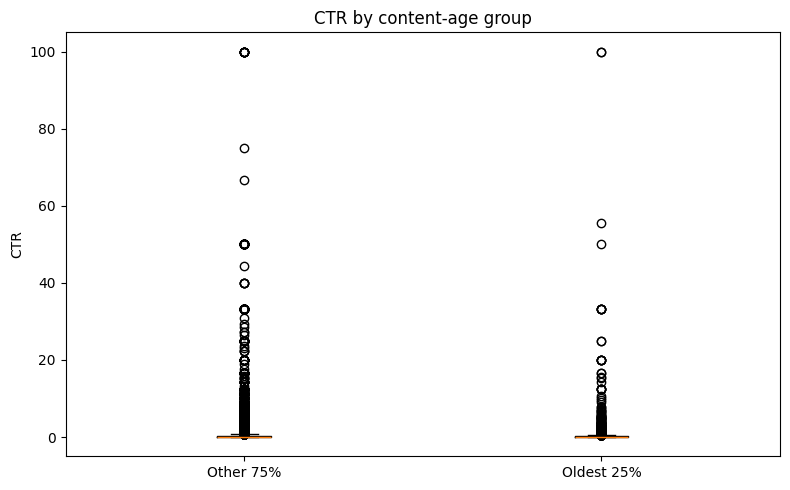

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        other_ctr,
        older_ctr
    ],
    labels=[
        "Other 75%",
        "Oldest 25%"
    ]
)

plt.ylabel("CTR")
plt.title("CTR by content-age group")
plt.tight_layout()
plt.show()

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The signal tests are evidence for prioritization, not proof of what caused a page's performance. Signals that show consistent directional relationships can be retained as review inputs, while mixed signals should be treated as prompts for human inspection rather than automatic decisions.

The resulting queue should therefore help a content team decide **what to inspect first**, while the final refresh decision remains with a human reviewer.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

print("Practical interpretation")
print("-" * 60)

print(
    f"Content age signal: {age_verdict}. "
    f"Spearman rho = {rho_age:.4f}."
)

print(
    f"CTR signal: {ctr_verdict}. "
    f"Spearman rho = {rho_ctr:.4f}."
)

print(
    f"Search-volume signal: {volume_verdict}. "
    f"Spearman rho = {rho_volume:.4f}."
)

print(
    f"Flag-linked STALE_CONTENT test: {flag_verdict}. "
    f"Median CTR difference (older - other) = {median_difference:.4f}."
)

print("\nPractical takeaway:")
print(
    "These results should be used as directional decision-support signals. "
    "They help prioritize pages for human review, but they do not establish "
    "causation or guarantee that refreshing a page will improve performance."
)



Practical interpretation
------------------------------------------------------------
Content age signal: MIXED. Spearman rho = -0.0585.
CTR signal: CONFIRMED. Spearman rho = -0.1444.
Search-volume signal: MIXED. Spearman rho = -0.0756.
Flag-linked STALE_CONTENT test: CONFIRMED. Median CTR difference (older - other) = -0.0300.

Practical takeaway:
These results should be used as directional decision-support signals. They help prioritize pages for human review, but they do not establish causation or guarantee that refreshing a page will improve performance.


In [ ]:
print("=" * 60)
print("ML-06 SIGNAL AUDIT SUMMARY")
print("=" * 60)

print(f"Content age → CTR:       {age_verdict}")
print(f"CTR → average position:  {ctr_verdict}")
print(f"Search volume → CTR:     {volume_verdict}")
print(f"STALE_CONTENT test:      {flag_verdict}")

print("\nKey dataset facts:")
print(f"Rows: {len(df):,}")
print(f"Unique pages: {df['content_id'].nunique():,}")
print(f"Unique clients: {df['client_id'].nunique():,}")

print("\nInterpretation:")
print(
    "These tests provide directional evidence only. "
    "They do not establish causation or guarantee that refreshing a page "
    "will improve search performance."
)

ML-06 SIGNAL AUDIT SUMMARY
Content age → CTR:       MIXED
CTR → average position:  CONFIRMED
Search volume → CTR:     MIXED
STALE_CONTENT test:      CONFIRMED

Key dataset facts:
Rows: 30,000
Unique pages: 30,000
Unique clients: 32

Interpretation:
These tests provide directional evidence only. They do not establish causation or guarantee that refreshing a page will improve search performance.


## Self-check

* Every section above is filled — markdown thinking AND the code that backs it.
* The notebook runs top to bottom with no errors (`Runtime → Run all`).
* No client names, URLs, or private queries appear in the notebook.
* Claims use careful words such as observed, measured, directional, and decision-support.
* The signal verdicts are generated from the observed results rather than manually chosen.
* The flag-linked test is treated as evidence for review, not proof of causation.
* The notebook is committed under `work/notebooks/`.
